# Baseline Model: Logistic Regression on TF-IDF

This notebook builds and evaluates our baseline model — a Logistic Regression classifier trained on TF-IDF features extracted from article text. As an inherently interpretable model, it serves as both a performance reference point and a transparent benchmark for comparing against more complex models in later notebooks.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score
)

from preprocessing import (
    preprocess_text, get_tfidf_features,
    get_train_test_split, RANDOM_STATE
)

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2. Load Cleaned Dataset

In [2]:
df = pd.read_csv("Dataset/fake_news_dataset_cleaned.csv")
df[["title", "text", "label", "label_encoded"]].head()

,title,text,label,label_encoded
0,Foreign Democrat final.,more tax development both store agreement lawy...,real,1
1,To offer down resource great point.,probably guess western behind likely next inve...,fake,0
2,Himself church myself carry.,them identify forward present success risk sev...,fake,0
3,You unit its should.,phone which item yard Republican safe where po...,fake,0
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,fake,0


## 3. Text Preprocessing (NLP Pipeline)

Combine `title` + `text`, then apply: lowercasing → punctuation/special character removal → tokenization → stopword removal → lemmatization.

In [3]:
df["full_text"] = df["title"] + " " + df["text"]
df["processed_text"] = df["full_text"].apply(preprocess_text)
df[["full_text", "processed_text"]].head()

,full_text,processed_text
0,Foreign Democrat final. more tax development b...,foreign democrat final tax development store a...
1,To offer down resource great point. probably g...,offer resource great point probably guess west...
2,Himself church myself carry. them identify for...,church carry identify forward present success ...
3,You unit its should. phone which item yard Rep...,unit phone item yard republican safe police id...
4,Billion believe employee summer how. wonder my...,billion believe employee summer wonder fact di...


In [4]:
print("RAW:\n", df["full_text"].iloc[0][:300])
print("\nPROCESSED:\n", df["processed_text"].iloc[0][:300])

RAW:
 Foreign Democrat final. more tax development both store agreement lawyer hear outside continue reach difference yeah figure your power fear identify there protect security great national nothing fast story why late nearly bit cost tough since question to power almost future young conference behind a

PROCESSED:
 foreign democrat final tax development store agreement lawyer hear outside continue reach difference yeah figure power fear identify protect security great national nothing fast story late nearly bit cost tough since question power almost future young conference behind ahead building teach million b


## 4. TF-IDF Vectorization (Unigrams + Bigrams)

In [5]:
X, y, tfidf = get_tfidf_features(df)
print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (20000, 5000)


## 5. Train/Test Split

Fixed `random_state` and `stratify=y` ensure this exact split is reused identically across every model in this project.

In [6]:
X_train, X_test, y_train, y_test = get_train_test_split(X, y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (16000, 5000)
Test shape: (4000, 5000)

Train class balance:
 label_encoded
0    0.503
1    0.497
Name: proportion, dtype: float64

Test class balance:
 label_encoded
0    0.503
1    0.497
Name: proportion, dtype: float64


## 6. Train Baseline Model: Logistic Regression

In [7]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

## 7. Evaluation

Recall on the **Fake** class (`label_encoded = 0`) is the primary metric, per the project's trust-and-safety framing.

In [8]:
print(classification_report(y_test, y_pred, target_names=["fake", "real"]))

recall_fake = recall_score(y_test, y_pred, pos_label=0)
print(f"Recall on Fake class (primary metric): {recall_fake:.4f}")

              precision    recall  f1-score   support

        fake       0.51      0.52      0.51      2011
        real       0.50      0.49      0.49      1989

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000

Recall on Fake class (primary metric): 0.5216


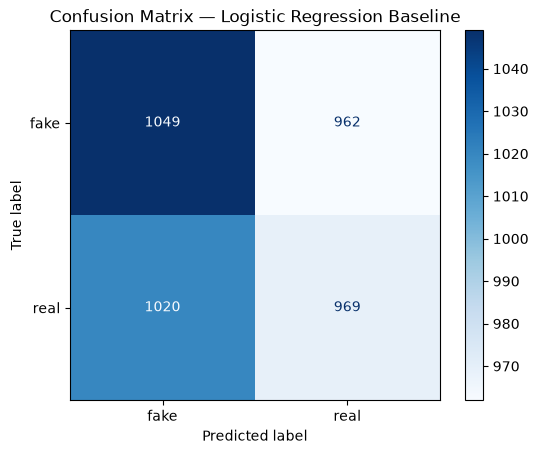

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fake", "real"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.show()

- True Positive, correctly caught fake news article: 1,049
- False Negative, fake news article predicted as real: 962
- False Positive, real article predicted as fake: 1,020
- True Negative, correctly identified real article: 969

With a Fake-class recall of only ~52% (display above), the baseline model is barely better than random guessing; far from reliable enough to support a trust-and-safety reviewer's decision, and suggests either weak linguistic signal in the text or a preprocessing issue that needs investigation before comparing against more complex models.

## 8. Interpretability: Coefficients → Odds Ratios

Since logistic regression is inherently interpretable, no post-hoc explanation method is needed. Coefficients map directly to specific words/n-grams.

In [10]:
feature_names = tfidf.get_feature_names_out()
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    "term": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

print("Top 15 terms pushing toward REAL (label_encoded=1):")
display(coef_df.sort_values("coefficient", ascending=False).head(15))

print("\nTop 15 terms pushing toward FAKE (label_encoded=0):")
display(coef_df.sort_values("coefficient", ascending=True).head(15))

Top 15 terms pushing toward REAL (label_encoded=1):


,term,coefficient,odds_ratio
459,big,1.326306,3.767102
1703,girl,1.263754,3.538682
1181,economy,1.237377,3.446562
3546,radio,1.129390,3.093770
2452,member,1.116949,3.055519
3704,responsibility,1.018582,2.769266
545,build,1.012778,2.753238
3821,season,1.004841,2.731472
4644,two,0.996127,2.707776
3661,remain,0.993970,2.701940



Top 15 terms pushing toward FAKE (label_encoded=0):


,term,coefficient,odds_ratio
3968,significant,-1.561994,0.209717
4382,take,-1.501220,0.222858
1731,good,-1.485942,0.226289
735,claim,-1.336544,0.262752
137,along,-1.246635,0.287470
2525,moment,-1.213315,0.297210
3233,pick,-1.107331,0.330440
3733,rich,-1.091942,0.335564
128,alone,-1.080286,0.339498
3005,offer,-1.052080,0.349211


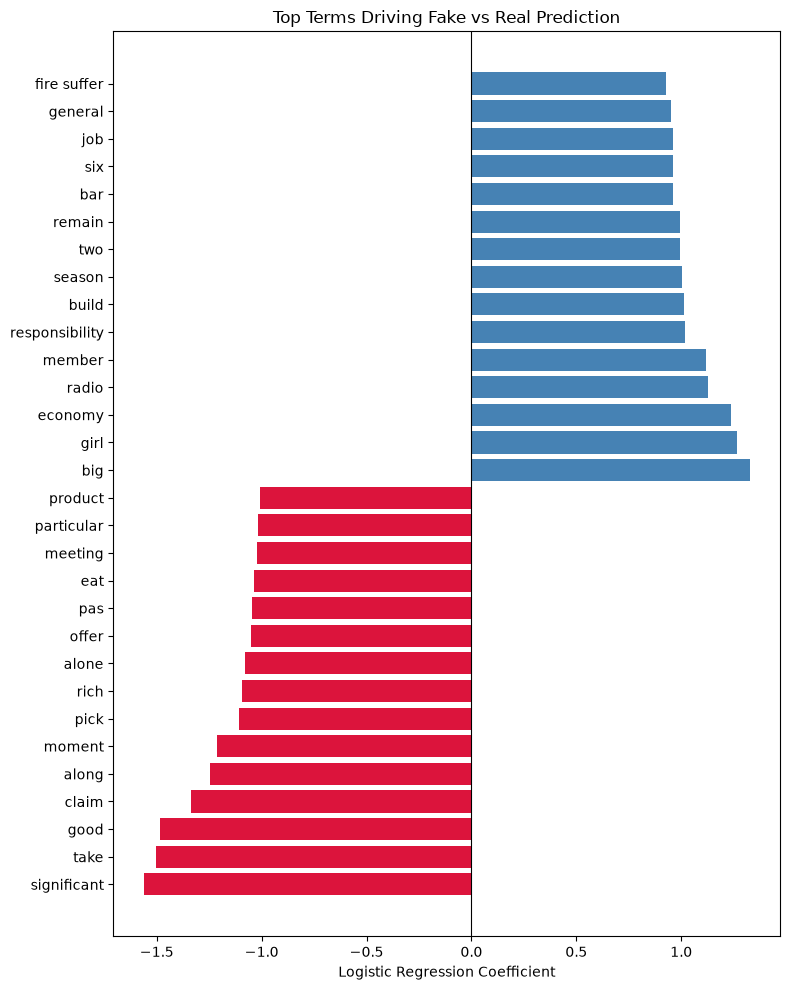

In [11]:
top_n = 15
top_real = coef_df.sort_values("coefficient", ascending=False).head(top_n)
top_fake = coef_df.sort_values("coefficient", ascending=True).head(top_n)
plot_df = pd.concat([top_fake, top_real])

plt.figure(figsize=(8, 10))
colors = ["crimson" if c < 0 else "steelblue" for c in plot_df["coefficient"]]
plt.barh(plot_df["term"], plot_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top Terms Driving Fake vs Real Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

## 9. Sanity Check: Shortcut / Leakage Inspection

Before trusting these results, check whether any top terms look like leaked metadata (e.g., outlet names, bylines) rather than genuine linguistic markers of fake/real reporting.

In [12]:
suspicious_terms = ["reuters", "cnn", "bbc", "guardian", "fox", "times", "global"]
flagged = coef_df[coef_df["term"].str.contains("|".join(suspicious_terms), case=False, na=False)]
display(flagged.sort_values("coefficient"))

,term,coefficient,odds_ratio
4114,sometimes show,-0.383995,0.681135
4113,sometimes future,-0.308545,0.734515
4921,worker sometimes,-0.300744,0.740268
4112,sometimes,0.722000,2.058546


### Why No LIME/SHAP/PDP/ICE for Logistic Regression

Logistic regression is inherently interpretable; its coefficients directly represent how each word/n-gram contributes to the prediction, with no approximation involved. Post-hoc explanation methods (LIME, SHAP, PDP, ICE) exist specifically to approximate or probe black-box models from the outside; applying them here would be redundant, since the model's own parameters already provide an exact, direct explanation. These methods become necessary starting with the next tier (Random Forest, XGBoost, LightGBM, SVM, Decision Trees), where the models are no longer transparent by design.